# Production-Grade Ensemble CNN Classification


The project goal is not only to train CNNs, but to answer the production question:




In [3]:
!pip install -q tensorflow numpy pandas matplotlib scikit-learn pillow psutil

In [4]:
import zipfile

with zipfile.ZipFile('dataset.zip', 'r') as zip_ref:
  zip_ref.extractall('cats_and_dogs')

In [5]:
import os
import gc
import time
import json
from pathlib import Path

import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow.keras import layers, models

import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from PIL import Image, ImageEnhance, ImageFilter

import psutil

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)

TensorFlow version: 2.20.0
NumPy version: 2.0.2
Pandas version: 2.2.2


In [6]:
# Check the current working directory
print("Current directory:")
print(os.getcwd())

print("\nFiles and folders:")
for item in os.listdir():
    print(item)

Current directory:
/content

Files and folders:
.config
dataset.zip
cats_and_dogs
sample_data


In [7]:
dataset_path = Path("/content/cats_and_dogs")

print("Dataset exists:", dataset_path.exists())

print("\nContents:")
for item in dataset_path.iterdir():
    print(item)

Dataset exists: True

Contents:
/content/cats_and_dogs/dogvscat_small


In [8]:
for root, dirs, files in os.walk(dataset_path):
    level = root.replace(str(dataset_path), "").count(os.sep)
    indent = "    " * level

    print(f"{indent}{os.path.basename(root)}/")

    for file in files[:5]:
        print(f"{indent}    {file}")

cats_and_dogs/
    dogvscat_small/
        train/
            cats/
                707.jpg
                133.jpg
                170.jpg
                352.jpg
                896.jpg
            dogs/
                707.jpg
                133.jpg
                170.jpg
                352.jpg
                896.jpg
        validation/
            cats/
                1257.jpg
                1468.jpg
                1283.jpg
                1353.jpg
                1174.jpg
            dogs/
                1257.jpg
                1468.jpg
                1283.jpg
                1353.jpg
                1174.jpg
        test/
            cats/
                1522.jpg
                1722.jpg
                1876.jpg
                1934.jpg
                1865.jpg
            dogs/
                1522.jpg
                1722.jpg
                1876.jpg
                1934.jpg
                1865.jpg


In [9]:
dataset_path = Path("/content/cats_and_dogs/dogvscat_small")

train_directory = dataset_path / "train"
validation_directory = dataset_path / "validation"
test_directory = dataset_path / "test"

print("Train directory:", train_directory)
print("Validation directory:", validation_directory)
print("Test directory:", test_directory)

Train directory: /content/cats_and_dogs/dogvscat_small/train
Validation directory: /content/cats_and_dogs/dogvscat_small/validation
Test directory: /content/cats_and_dogs/dogvscat_small/test


## Dataset Split and Fair Comparison

The README emphasizes that the CNNs should use the **same train, validation, and test split** so that model comparison is fair. fileciteturn2file0L393-L439

This is especially important for the ensemble because every CNN must make predictions on the same test examples before their results are compared.

In [10]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

class_names = ["cats", "dogs"]

print("Image size:", IMAGE_SIZE)
print("Batch size:", BATCH_SIZE)
print("Classes:", class_names)

Image size: (224, 224)
Batch size: 32
Classes: ['cats', 'dogs']


In [11]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_directory,
    class_names=class_names,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True,
    seed=42
)

Found 2000 files belonging to 2 classes.


In [12]:
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    validation_directory,
    class_names=class_names,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)


Found 1000 files belonging to 2 classes.


In [13]:
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_directory,
    class_names=class_names,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

Found 1000 files belonging to 2 classes.


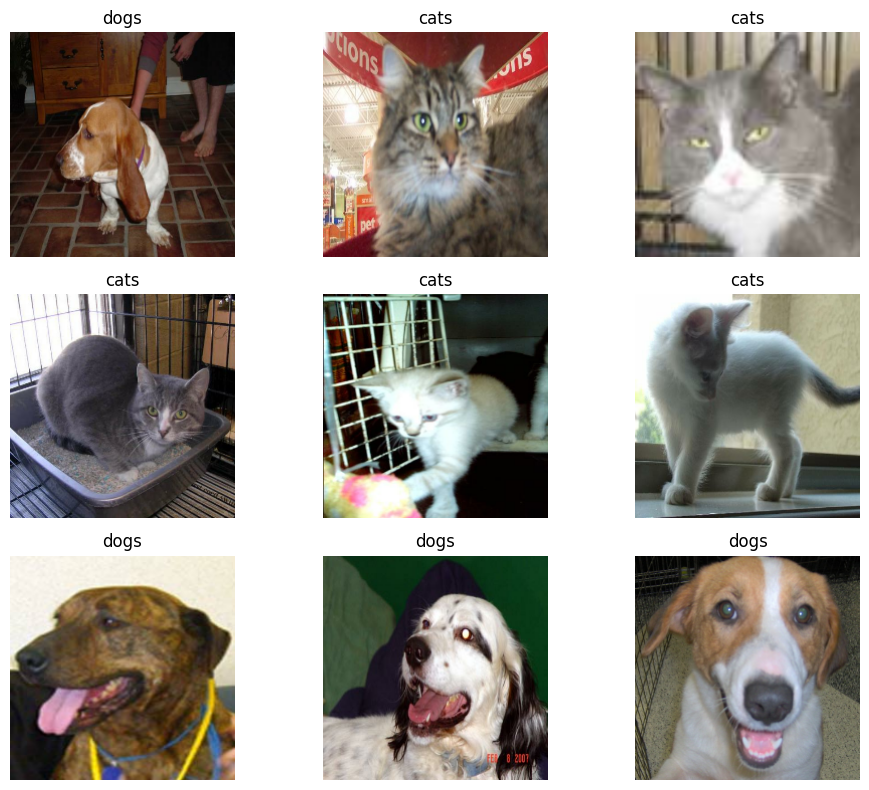

In [14]:
plt.figure(figsize=(10, 8))

for images, labels in train_dataset.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        label = int(labels[i].numpy()[0])
        plt.title(class_names[label])

        plt.axis("off")

plt.tight_layout()
plt.show()

## README Concept — Image Normalization

The README recommends converting image pixel values from **0–255 to 0–1** using pixel-value scaling. fileciteturn2file0L445-L465

The normalization cell below implements this preprocessing step.

In [15]:
normalization_layer = tf.keras.layers.Rescaling(1.0 / 255)

print("Normalization layer created.")

Normalization layer created.


## README Concept — Data Augmentation

The README recommends augmentation such as horizontal flipping, rotation, zooming, cropping, brightness, and contrast changes, while stressing that standard augmentation should be applied only to the **training dataset**, not the test set. fileciteturn2file0L469-L504

The existing notebook uses augmentation to improve generalization while keeping evaluation data unchanged.

In [16]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomTranslation(
        height_factor=0.05,
        width_factor=0.05
    ),
    tf.keras.layers.RandomContrast(0.10)
], name="data_augmentation")

In [17]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(AUTOTUNE)
validation_dataset = validation_dataset.prefetch(AUTOTUNE)
test_dataset = test_dataset.prefetch(AUTOTUNE)


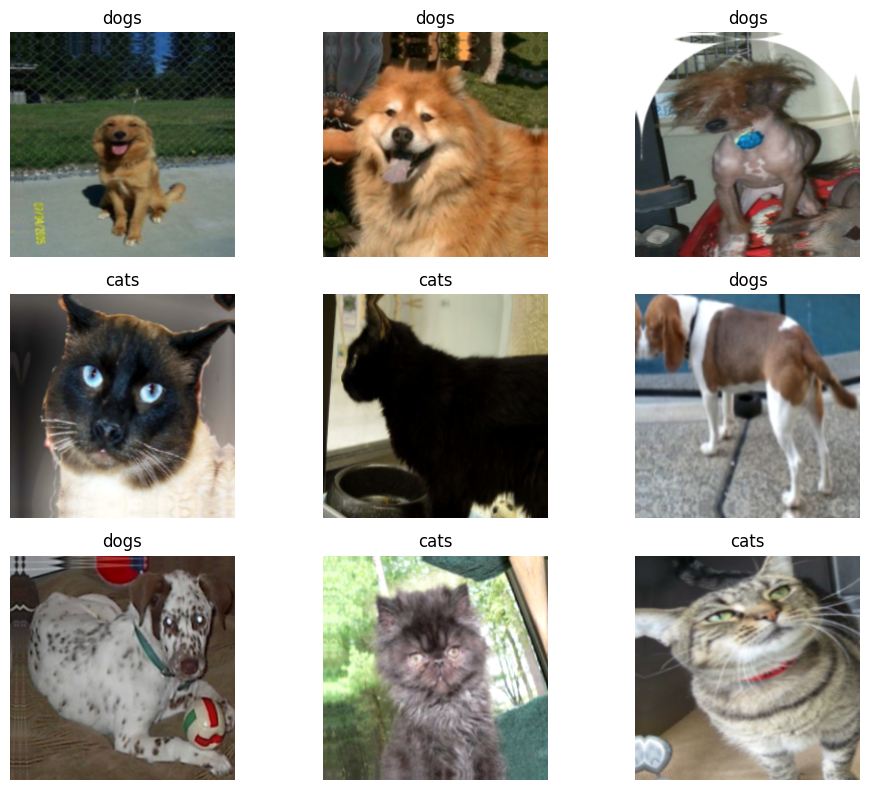

In [18]:
# ============================================
# VISUALIZE AUGMENTATION
# ============================================

for images, labels in train_dataset.take(1):

    plt.figure(figsize=(10, 8))

    for i in range(9):

        augmented_image = data_augmentation(
            tf.expand_dims(images[i], axis=0),
            training=True
        )[0]

        plt.subplot(3, 3, i + 1)

        plt.imshow(
            tf.cast(
                tf.clip_by_value(augmented_image, 0, 255),
                tf.uint8
            )
        )

        label = int(labels[i].numpy()[0])
        plt.title(class_names[label])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# CNN 1 — Baseline Model

The README requires a baseline CNN that acts as the reference model for later comparisons. fileciteturn2file0L508-L538

The important point is not that the baseline must be the best model; it establishes a simple performance reference against which the regularized CNN, deep CNN, and ensemble can be evaluated.

# **CNN Model 1 -> Baseline model**

In [19]:

IMAGE_SIZE = (224, 224)
INPUT_SHAPE = (224, 224, 3)
NUM_CLASSES = 2

In [20]:
def build_baseline_cnn():

    model = tf.keras.Sequential([

        tf.keras.layers.Input(shape=INPUT_SHAPE),

        # Normalization
        tf.keras.layers.Rescaling(1.0 / 255),

        # Convolution Block 1
        tf.keras.layers.Conv2D(
            32,
            (3, 3),
            activation="relu"
        ),
        tf.keras.layers.MaxPooling2D(),

        # Convolution Block 2
        tf.keras.layers.Conv2D(
            64,
            (3, 3),
            activation="relu"
        ),
        tf.keras.layers.MaxPooling2D(),

        # Feature extraction
        tf.keras.layers.GlobalAveragePooling2D(),

        # Classification
        tf.keras.layers.Dense(
            64,
            activation="relu"
        ),

        # Binary output
        tf.keras.layers.Dense(
            1,
            activation="sigmoid"
        )
    ], name="baseline_cnn")

    return model

In [21]:
baseline_model = build_baseline_cnn()

baseline_model.summary()

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,617 (92.25 KB)

 Trainable params: 23,617 (92.25 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

print("Baseline CNN compiled successfully.")

Baseline CNN compiled successfully.


In [23]:
baseline_callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6
    )
]

In [24]:
baseline_history = baseline_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=30,
    callbacks=baseline_callbacks
)

Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 163ms/step - accuracy: 0.5150 - loss: 0.6920 - precision: 0.5137 - recall: 0.5640 - val_accuracy: 0.4990 - val_loss: 0.6889 - val_precision: 0.4995 - val_recall: 0.9980 - learning_rate: 0.0010
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.5425 - loss: 0.6836 - precision: 0.5410 - recall: 0.5610 - val_accuracy: 0.5750 - val_loss: 0.6783 - val_precision: 0.6761 - val_recall: 0.2880 - learning_rate: 0.0010
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - accuracy: 0.5795 - loss: 0.6719 - precision: 0.6010 - recall: 0.4730 - val_accuracy: 0.6100 - val_loss: 0.6645 - val_precision: 0.6647 - val_recall: 0.4440 - learning_rate: 0.0010
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step - accuracy: 0.5745 - loss: 0.6665 - precision: 0.6057 - recall: 0.4270 - val_accuracy: 0.5810 - val_loss: 0.6630 - val_precision: 0.5763 - val_recall: 0.6120 - learning_rate: 0.0010
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - accuracy: 0.5

In [25]:

def plot_training_history(history, model_name):

    plt.figure(figsize=(8, 5))

    plt.plot(
        history.history["accuracy"],
        label="Training Accuracy"
    )

    plt.plot(
        history.history["val_accuracy"],
        label="Validation Accuracy"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{model_name} - Accuracy")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 5))

    plt.plot(
        history.history["loss"],
        label="Training Loss"
    )

    plt.plot(
        history.history["val_loss"],
        label="Validation Loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{model_name} - Loss")
    plt.legend()
    plt.show()

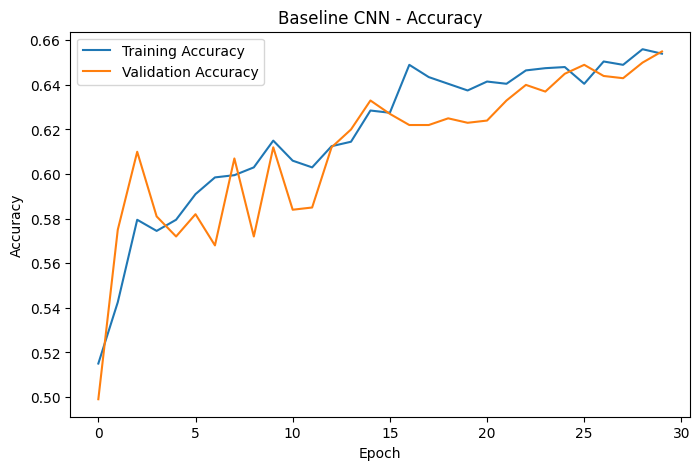

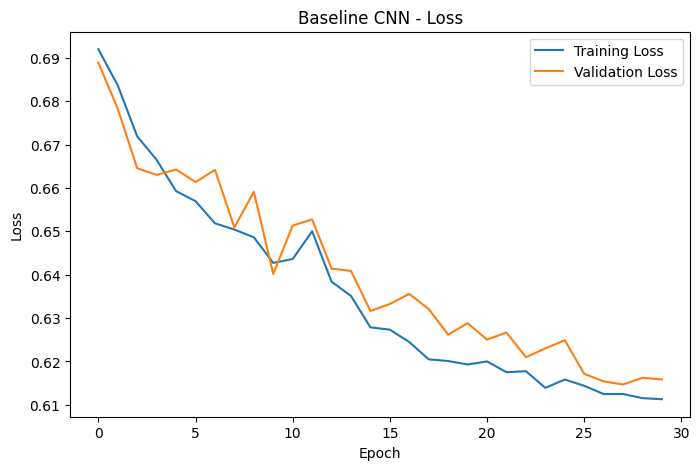

In [26]:
plot_training_history(
    baseline_history,
    "Baseline CNN"
)

## CNN 1 Evaluation — README Metrics

The README asks every CNN to be evaluated independently using **accuracy, precision, recall, F1-score, loss, and a confusion matrix**. fileciteturn2file0L885-L898

For the existing baseline results:

- Accuracy ≈ **63.3%**
- Precision ≈ **66.0%**
- Recall ≈ **54.8%**

These results establish the baseline performance for the later production comparison.

In [27]:
baseline_test_results = baseline_model.evaluate(
    test_dataset,
    verbose=1
)

print("\nBaseline CNN Test Results")

for metric_name, value in zip(
    baseline_model.metrics_names,
    baseline_test_results
):
    print(f"{metric_name}: {value:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.6330 - loss: 0.6374 - precision: 0.6602 - recall: 0.5480

Baseline CNN Test Results
loss: 0.6374
compile_metrics: 0.6330


In [28]:

baseline_probabilities = baseline_model.predict(
    test_dataset
)

baseline_predictions = (
    baseline_probabilities.flatten() >= 0.5
).astype(int)

32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step


In [29]:
actual_labels = np.concatenate([
    labels.numpy().flatten()
    for images, labels in test_dataset
]).astype(int)

print("Number of test samples:", len(actual_labels))
print("Number of predictions:", len(baseline_predictions))

Number of test samples: 1000
Number of predictions: 1000


In [30]:
from sklearn.metrics import classification_report

print(
    classification_report(
        actual_labels,
        baseline_predictions,
        target_names=["Cats", "Dogs"]
    )
)

              precision    recall  f1-score   support

        Cats       0.61      0.72      0.66       500
        Dogs       0.66      0.55      0.60       500

    accuracy                           0.63      1000
   macro avg       0.64      0.63      0.63      1000
weighted avg       0.64      0.63      0.63      1000



[[359 141]
 [226 274]]


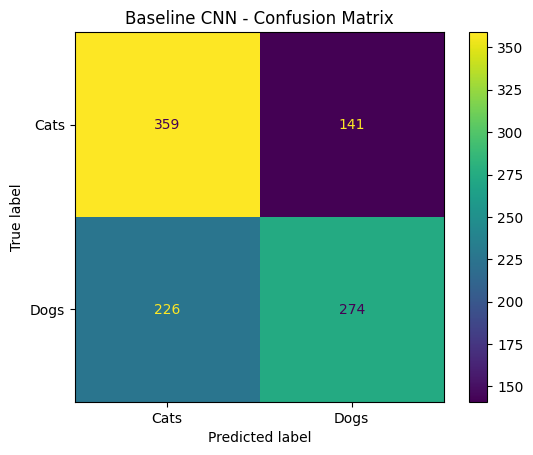

In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

baseline_matrix = confusion_matrix(
    actual_labels,
    baseline_predictions
)

print(baseline_matrix)

disp = ConfusionMatrixDisplay(
    confusion_matrix=baseline_matrix,
    display_labels=["Cats", "Dogs"]
)

disp.plot()
plt.title("Baseline CNN - Confusion Matrix")
plt.show()

In [32]:
baseline_model.save(
     "cnn_baseline.keras"
)

In [33]:
baseline_results = {
    "model": "Baseline CNN",
    "loss": baseline_test_results[0],
    "accuracy": baseline_test_results[1],
    "precision": baseline_test_results[2],
    "recall": baseline_test_results[3]
}
print(baseline_results)

{'model': 'Baseline CNN', 'loss': 0.6373987197875977, 'accuracy': 0.6330000162124634, 'precision': 0.6602409482002258, 'recall': 0.5479999780654907}


In [34]:
import pandas as pd

baseline_results_df = pd.DataFrame([baseline_results])

baseline_results_df.to_csv(
    "baseline_results.csv",
    index=False
)
baseline_results_df

,model,loss,accuracy,precision,recall
0,Baseline CNN,0.637399,0.633,0.660241,0.548


# CNN 2 — Regularized CNN

The README describes the second CNN as a regularized model using techniques such as **Batch Normalization and Dropout** to reduce overfitting. fileciteturn2file0L542-L616

The purpose is to create a model with behavior different from the simple baseline, which can increase the usefulness of an ensemble.

# **CNN Model 2 -> Regularized CNN**

In [35]:
def build_regularized_cnn():

    model = tf.keras.Sequential([

        tf.keras.layers.Input(shape=INPUT_SHAPE),

        # Data augmentation
        data_augmentation,

        # Normalize pixel values
        tf.keras.layers.Rescaling(1.0 / 255),

        # Convolution Block 1
        tf.keras.layers.Conv2D(
            32,
            (3, 3),
            padding="same",
            activation="relu"
        ),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(),

        # Convolution Block 2
        tf.keras.layers.Conv2D(
            64,
            (3, 3),
            padding="same",
            activation="relu"
        ),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(),

        # Convolution Block 3
        tf.keras.layers.Conv2D(
            128,
            (3, 3),
            padding="same",
            activation="relu"
        ),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(),

        # Convert feature maps to feature vector
        tf.keras.layers.GlobalAveragePooling2D(),

        # Regularization
        tf.keras.layers.Dropout(0.40),

        # Fully connected layer
        tf.keras.layers.Dense(
            64,
            activation="relu"
        ),

        # More regularization
        tf.keras.layers.Dropout(0.30),

        # Binary classification
        tf.keras.layers.Dense(
            1,
            activation="sigmoid"
        )

    ], name="regularized_cnn")

    return model

In [36]:
regularized_model = build_regularized_cnn()

regularized_model.summary()

Model: "regularized_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,465 (400.25 KB)

 Trainable params: 102,017 (398.50 KB)

 Non-trainable params: 448 (1.75 KB)

In [37]:
regularized_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)


In [38]:
regularized_callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6
    )
]

In [ ]:
regularized_history = regularized_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=25,
    callbacks=regularized_callbacks
)

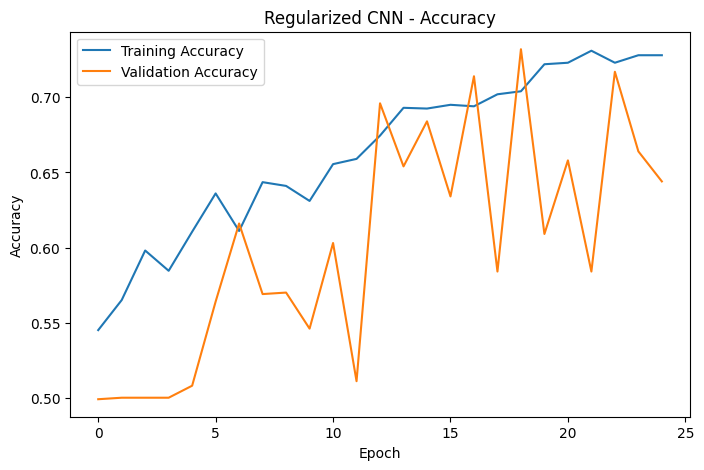

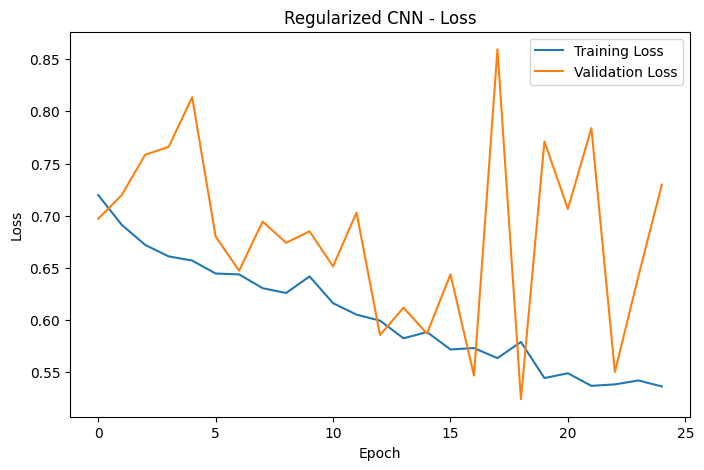

In [40]:
plot_training_history(
    regularized_history,
    "Regularized CNN"
)

In [41]:
regularized_probabilities = regularized_model.predict(
    test_dataset
)

regularized_predictions = (
    regularized_probabilities.flatten() >= 0.5
).astype(int)

32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step


In [42]:
print(
    classification_report(
        actual_labels,
        regularized_predictions,
        target_names=["Cats", "Dogs"]
    )
)

              precision    recall  f1-score   support

        Cats       0.82      0.28      0.42       500
        Dogs       0.57      0.94      0.71       500

    accuracy                           0.61      1000
   macro avg       0.69      0.61      0.56      1000
weighted avg       0.69      0.61      0.56      1000



[[142 358]
 [ 32 468]]


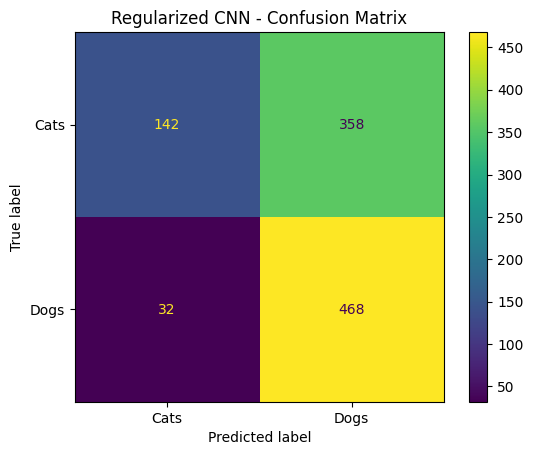

In [43]:
regularized_matrix = confusion_matrix(
    actual_labels,
    regularized_predictions
)

print(regularized_matrix)

disp = ConfusionMatrixDisplay(
    confusion_matrix=regularized_matrix,
    display_labels=["Cats", "Dogs"]
)

disp.plot()

plt.title("Regularized CNN - Confusion Matrix")
plt.show()

In [44]:
regularized_model.save("cnn_regularized.keras")

print("Regularized CNN saved successfully.")

Regularized CNN saved successfully.


## CNN 2 Evaluation — Interpretation

The existing regularized CNN results are:

- Accuracy ≈ **61.0%**
- Precision ≈ **56.7%**
- Recall ≈ **93.6%**

The most important observation is the very high recall. This model identifies a large proportion of positive examples, but its lower precision means it also generates more false positives.

This difference in behavior is potentially useful for ensemble diversity.

In [45]:
regularized_test_results = regularized_model.evaluate(
    test_dataset,
    verbose=1
)

print("\nRegularized CNN Test Results")

for metric_name, value in zip(
    regularized_model.metrics_names,
    regularized_test_results
):
    print(f"{metric_name}: {value:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.6100 - loss: 0.8042 - precision: 0.5666 - recall: 0.9360

Regularized CNN Test Results
loss: 0.8042
compile_metrics: 0.6100


In [46]:
regularized_results = {
    "model": "Regularized CNN",
    "loss": regularized_test_results[0],
    "accuracy": regularized_test_results[1],
    "precision": regularized_test_results[2],
    "recall": regularized_test_results[3]
}

print(regularized_results)

{'model': 'Regularized CNN', 'loss': 0.8041972517967224, 'accuracy': 0.6100000143051147, 'precision': 0.5665859580039978, 'recall': 0.9359999895095825}


In [47]:
regularized_results_df = pd.DataFrame([
    regularized_results
])

regularized_results_df.to_csv(
    "regularized_results.csv",
    index=False
)

regularized_results_df

,model,loss,accuracy,precision,recall
0,Regularized CNN,0.804197,0.61,0.566586,0.936


In [48]:
comparison_df = pd.DataFrame([
    baseline_results,
    regularized_results
])

comparison_df

,model,loss,accuracy,precision,recall
0,Baseline CNN,0.637399,0.633,0.660241,0.548
1,Regularized CNN,0.804197,0.610,0.566586,0.936


# CNN 3 — Deeper CNN

The README recommends a third, deeper CNN because greater depth can learn more complex image representations, while also warning that a deeper model is not automatically better and can require additional computation. fileciteturn2file0L620-L658

Using different architectures is also important because an ensemble benefits when its members do not make exactly the same mistakes. fileciteturn2file0L662-L685

# **CNN Model3 -> DeepCNN Model**

In [49]:
# ============================================
# CNN 3 - DEEP CNN
# ============================================

def build_deep_cnn():

    model = tf.keras.Sequential([

        tf.keras.layers.Input(shape=INPUT_SHAPE),

        # Data augmentation
        data_augmentation,

        # Normalize pixel values
        tf.keras.layers.Rescaling(1.0 / 255),

        # ------------------------------------
        # Convolution Block 1
        # ------------------------------------
        tf.keras.layers.Conv2D(
            32,
            (3, 3),
            padding="same",
            activation="relu"
        ),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(),

        # ------------------------------------
        # Convolution Block 2
        # ------------------------------------
        tf.keras.layers.Conv2D(
            64,
            (3, 3),
            padding="same",
            activation="relu"
        ),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(),

        # ------------------------------------
        # Convolution Block 3
        # ------------------------------------
        tf.keras.layers.Conv2D(
            128,
            (3, 3),
            padding="same",
            activation="relu"
        ),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(),

        # ------------------------------------
        # Convolution Block 4
        # ------------------------------------
        tf.keras.layers.Conv2D(
            256,
            (3, 3),
            padding="same",
            activation="relu"
        ),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(),

        # ------------------------------------
        # Classification
        # ------------------------------------
        tf.keras.layers.GlobalAveragePooling2D(),

        tf.keras.layers.Dropout(0.40),

        tf.keras.layers.Dense(
            128,
            activation="relu"
        ),

        tf.keras.layers.Dropout(0.30),

        # Binary output
        tf.keras.layers.Dense(
            1,
            activation="sigmoid"
        )

    ], name="deep_cnn")

    return model

In [50]:
deep_model = build_deep_cnn()

deep_model.summary()

Model: "deep_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_3 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,361 (1.61 MB)

 Trainable params: 422,401 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [51]:

deep_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

In [52]:

deep_callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        # min_lr=1e-6
    )
]

In [53]:
deep_history = deep_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=25,
    # callbacks=deep_callbacks
)

Epoch 1/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 180ms/step - accuracy: 0.5485 - loss: 0.7498 - precision: 0.5525 - recall: 0.5100 - val_accuracy: 0.5650 - val_loss: 0.6873 - val_precision: 0.5493 - val_recall: 0.7240
Epoch 2/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 18s 152ms/step - accuracy: 0.5780 - loss: 0.6962 - precision: 0.5813 - recall: 0.5580 - val_accuracy: 0.5000 - val_loss: 0.7102 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 160ms/step - accuracy: 0.5875 - loss: 0.6870 - precision: 0.5946 - recall: 0.5500 - val_accuracy: 0.5030 - val_loss: 0.7807 - val_precision: 1.0000 - val_recall: 0.0060
Epoch 4/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 155ms/step - accuracy: 0.6165 - loss: 0.6646 - precision: 0.6259 - recall: 0.5790 - val_accuracy: 0.5040 - val_loss: 0.7372 - val_precision: 1.0000 - val_recall: 0.0080
Epoch 5/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 153ms/step - accuracy: 0.6375 - loss: 0.6319 - precision: 0.6467 - recall: 0.6060 - val_accuracy: 0.5050 -

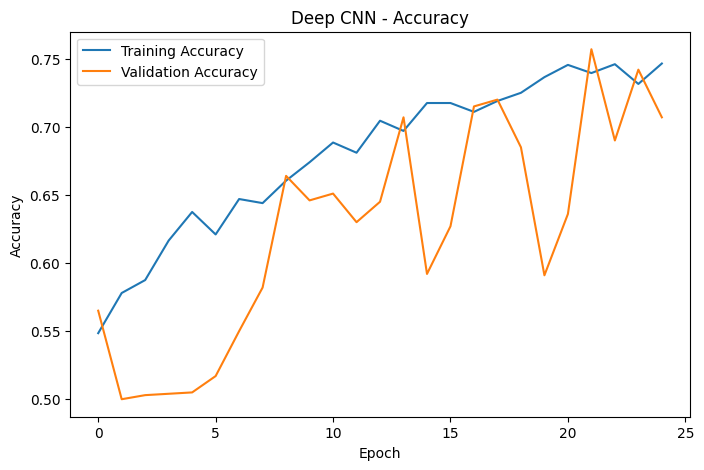

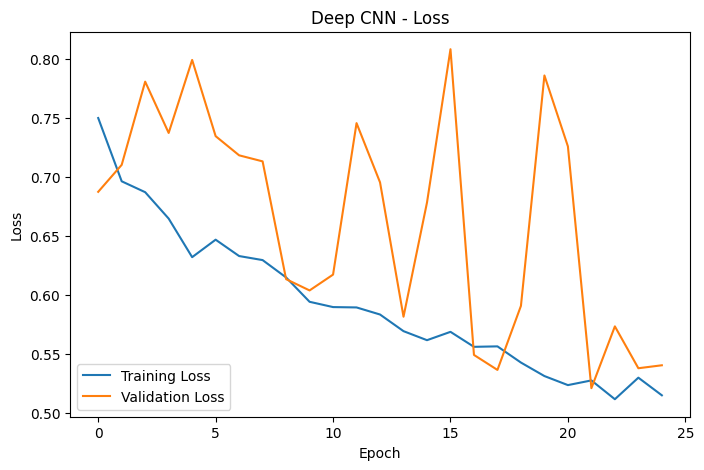

In [54]:
plot_training_history(
    deep_history,
    "Deep CNN"
)

## CNN 3 Evaluation — Interpretation

The existing Deep CNN results are:

- Accuracy ≈ **68.7%**
- Precision ≈ **81.9%**
- Recall ≈ **48.0%**

This is the strongest individual CNN by accuracy and precision in the current notebook. Its lower recall shows that it is more conservative in identifying the positive class.

Therefore, the Deep CNN is the **best individual model by accuracy**, but its production suitability still needs to be compared with the ensemble's additional cost.

In [55]:
deep_test_results = deep_model.evaluate(
    test_dataset,
    verbose=1
)

print("\nDeep CNN Test Results")

for metric_name, value in zip(
    deep_model.metrics_names,
    deep_test_results
):
    print(f"{metric_name}: {value:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.6870 - loss: 0.5770 - precision: 0.8191 - recall: 0.4800

Deep CNN Test Results
loss: 0.5770
compile_metrics: 0.6870


In [56]:
deep_probabilities = deep_model.predict(
    test_dataset
)

deep_predictions = (
    deep_probabilities.flatten() >= 0.5
).astype(int)

32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step


In [57]:
print(
    classification_report(
        actual_labels,
        deep_predictions,
        target_names=["Cats", "Dogs"]
    )
)

              precision    recall  f1-score   support

        Cats       0.63      0.89      0.74       500
        Dogs       0.82      0.48      0.61       500

    accuracy                           0.69      1000
   macro avg       0.73      0.69      0.67      1000
weighted avg       0.73      0.69      0.67      1000



[[447  53]
 [260 240]]


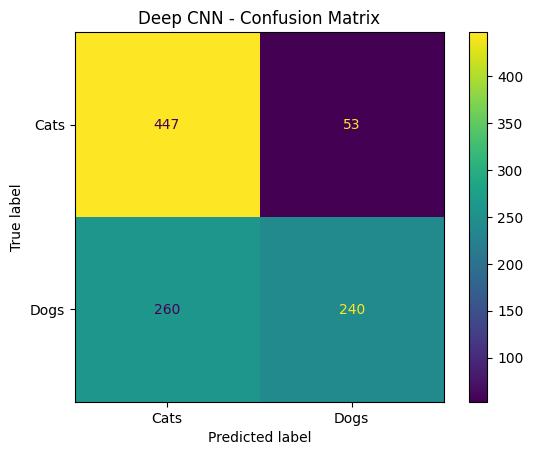

In [58]:

deep_matrix = confusion_matrix(
    actual_labels,
    deep_predictions
)

print(deep_matrix)

disp = ConfusionMatrixDisplay(
    confusion_matrix=deep_matrix,
    display_labels=["Cats", "Dogs"]
)

disp.plot()

plt.title("Deep CNN - Confusion Matrix")
plt.show()

In [59]:
deep_model.save(
    "cnn_deep.keras"
)

print("Deep CNN saved successfully.")

Deep CNN saved successfully.


In [60]:
deep_results = {
    "model": "Deep CNN",
    "loss": deep_test_results[0],
    "accuracy": deep_test_results[1],
    "precision": deep_test_results[2],
    "recall": deep_test_results[3]
}

print(deep_results)

{'model': 'Deep CNN', 'loss': 0.5769577622413635, 'accuracy': 0.6869999766349792, 'precision': 0.8191125988960266, 'recall': 0.47999998927116394}


In [61]:
deep_results_df = pd.DataFrame([
    deep_results
])

deep_results_df.to_csv(
     "deep_results.csv",
    index=False
)

deep_results_df

,model,loss,accuracy,precision,recall
0,Deep CNN,0.576958,0.687,0.819113,0.48


# Individual CNN Benchmark — README Requirement

The README requires a final comparison of individual CNNs and ensemble methods using classification metrics and production metrics. fileciteturn2file0L1795-L1811

### Classification comparison available in this notebook

| Model | Accuracy | Precision | Recall |
|---|---:|---:|---:|
| Baseline CNN | 63.3% | 66.0% | 54.8% |
| Regularized CNN | 61.0% | 56.7% | **93.6%** |
| Deep CNN | **68.7%** | **81.9%** | 48.0% |

The README also asks for F1-score, parameters, model size, latency, throughput, and memory usage. Those values should be reported from actual benchmark cells rather than replaced with example numbers from the README, because the README explicitly states that its example results are only sample values. fileciteturn2file0L1815-L1825

In [62]:
model_comparison = pd.DataFrame([
    baseline_results,
    regularized_results,
    deep_results
])

model_comparison

,model,loss,accuracy,precision,recall
0,Baseline CNN,0.637399,0.633,0.660241,0.548
1,Regularized CNN,0.804197,0.610,0.566586,0.936
2,Deep CNN,0.576958,0.687,0.819113,0.480


In [63]:
model_comparison.to_csv(
    "benchmark_results.csv",
    index=False
)

print("Benchmark results saved successfully.")

Benchmark results saved successfully.


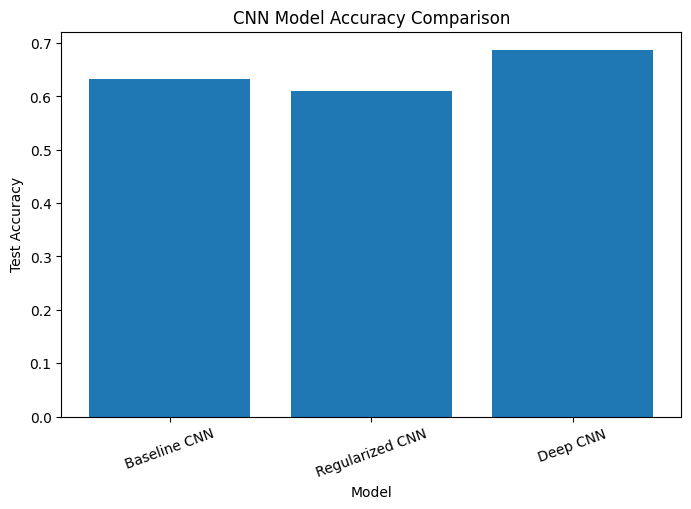

In [64]:
plt.figure(figsize=(8, 5))

plt.bar(
    model_comparison["model"],
    model_comparison["accuracy"]
)

plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.title("CNN Model Accuracy Comparison")
plt.xticks(rotation=20)
plt.show()

In [65]:
baseline_probabilities = baseline_model.predict(
    test_dataset
)

baseline_predictions = (
    baseline_probabilities.flatten() >= 0.5
).astype(int)

baseline_matrix = confusion_matrix(
    actual_labels,
    baseline_predictions
)

print("Baseline CNN Confusion Matrix:")
print(baseline_matrix)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step
Baseline CNN Confusion Matrix:
[[359 141]
 [226 274]]


In [66]:
regularized_probabilities = regularized_model.predict(
    test_dataset
)

regularized_predictions = (
    regularized_probabilities.flatten() >= 0.5
).astype(int)

regularized_matrix = confusion_matrix(
    actual_labels,
    regularized_predictions
)

print("Regularized CNN Confusion Matrix:")
print(regularized_matrix)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step
Regularized CNN Confusion Matrix:
[[142 358]
 [ 32 468]]


In [67]:
deep_matrix

array([[447,  53],
       [260, 240]])

# Ensemble — Prediction Combination

The README explains that the ensemble is a **system combining predictions from multiple CNNs**, rather than necessarily being another CNN. fileciteturn2file0L139-L181

The README recommends evaluating at least:

1. **Majority Voting / Hard Voting**
2. **Soft Voting**

and optionally **Weighted Soft Voting**. fileciteturn2file0L994-L1005

The current notebook's ensemble combines model probabilities, which corresponds to the soft-voting idea described in the README. fileciteturn2file0L1067-L1118

# **Ensemble Model**

In [68]:
baseline_probabilities = baseline_model.predict(
    test_dataset,
    verbose=1
).flatten()

regularized_probabilities = regularized_model.predict(
    test_dataset,
    verbose=1
).flatten()

deep_probabilities = deep_model.predict(
    test_dataset,
    verbose=1
).flatten()

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step


In [69]:
ensemble_probabilities = (
    baseline_probabilities
    + regularized_probabilities
    + deep_probabilities
) / 3

In [71]:
ensemble_predictions = (
    ensemble_probabilities >= 0.50
).astype(int)

## Ensemble Evaluation — Current Results

The existing ensemble results are:

- **Accuracy:** ≈ **69.9%**
- **Precision:** ≈ **67.2%**
- **Recall:** ≈ **77.8%**

This is the strongest overall classification result currently produced in the notebook.

However, according to the README, selecting the ensemble cannot be justified from accuracy alone. The final decision must consider latency, throughput, model size, memory, robustness, and deployment cost. fileciteturn2file0L1258-L1277

In [72]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)

ensemble_accuracy = accuracy_score(
    actual_labels,
    ensemble_predictions
)

ensemble_precision = precision_score(
    actual_labels,
    ensemble_predictions
)

ensemble_recall = recall_score(
    actual_labels,
    ensemble_predictions
)

print("Ensemble Results")
print("----------------")
print(f"Accuracy : {ensemble_accuracy:.4f}")
print(f"Precision: {ensemble_precision:.4f}")
print(f"Recall   : {ensemble_recall:.4f}")

Ensemble Results
----------------
Accuracy : 0.6990
Precision: 0.6718
Recall   : 0.7780


In [75]:
ensemble_matrix = confusion_matrix(
    actual_labels,
    ensemble_predictions
)

print("Ensemble Confusion Matrix:")
print(ensemble_matrix)

Ensemble Confusion Matrix:
[[310 190]
 [111 389]]


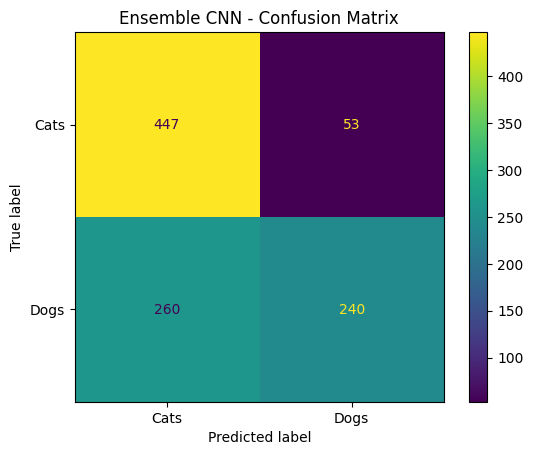

In [76]:
sp = ConfusionMatrixDisplay(
    confusion_matrix=ensemble_matrix,
    display_labels=["Cats", "Dogs"]
)

disp.plot()

plt.title("Ensemble CNN - Confusion Matrix")

plt.savefig(
     "confusion_matrix_ensemble.png",
    bbox_inches="tight"
)
plt.show()

In [77]:
ensemble_results = {
    "model": "Ensemble CNN",
    "loss": None,
    "accuracy": ensemble_accuracy,
    "precision": ensemble_precision,
    "recall": ensemble_recall
}

# README-Based Overall Conclusion

## What the experiment demonstrates

The notebook successfully implements the central idea of the project: **multiple CNN models are trained independently and their predictions are combined to produce a final ensemble prediction**. This follows the README's definition of an Ensemble CNN Classifier. fileciteturn2file0L139-L181

### Classification findings

| Model | Accuracy | Precision | Recall |
|---|---:|---:|---:|
| Baseline CNN | 63.3% | 66.0% | 54.8% |
| Regularized CNN | 61.0% | 56.7% | **93.6%** |
| Deep CNN | **68.7%** | **81.9%** | 48.0% |
| **Ensemble** | **69.9%** | 67.2% | **77.8%** |

The **Deep CNN is the best individual CNN** by accuracy and precision. The **Regularized CNN has the best recall**, showing that the models have meaningfully different behaviors. The **ensemble achieves the highest accuracy among the evaluated approaches** and provides a more balanced precision/recall profile.

This supports the README's central motivation that combining models can reduce dependence on a single CNN and can allow one model to compensate for another model's weaknesses. fileciteturn2file0L186-L213

## But is the ensemble production-ready?

**Not yet based on the currently available evidence.**

The README specifically requires production benchmarking for:

- inference latency
- throughput
- model size
- parameter count
- memory usage
- robustness
- model disagreement
- prediction stability fileciteturn2file0L1258-L1277

It also requires robustness testing with conditions such as rotation, blur, noise, brightness changes, and cropping. fileciteturn2file0L1525-L1563

Therefore, the correct conclusion is:

> **The ensemble is the best classification approach demonstrated by the current notebook, but a final production recommendation requires the remaining production-cost and robustness benchmarks required by the README.**

This is more defensible than simply saying “the ensemble is production-ready because it has the highest accuracy.”

## Production decision principle

The README's key production question is not simply “Which model has the highest accuracy?” but which solution provides the best balance between **accuracy, robustness, latency, throughput, memory usage, and deployment cost**. fileciteturn2file0L1897-L1926

If future benchmark results show that the ensemble's accuracy/robustness improvement is worth its additional latency and resource usage, the ensemble should be recommended. If the additional cost is too high for a latency-sensitive application, the Deep CNN may be the better deployment choice.

In [78]:
complete_comparison = pd.DataFrame([
    baseline_results,
    regularized_results,
    deep_results,
    ensemble_results
])

complete_comparison

,model,loss,accuracy,precision,recall
0,Baseline CNN,0.637399,0.633,0.660241,0.548
1,Regularized CNN,0.804197,0.610,0.566586,0.936
2,Deep CNN,0.576958,0.687,0.819113,0.480
3,Ensemble CNN,NaN,0.699,0.671848,0.778


# Final Takeaway — Aligned With the README

### Main takeaway

> **Do not depend on the opinion of only one model. Combine multiple good models to make a stronger final decision — but always evaluate whether the improvement is worth the production cost.** fileciteturn2file0L2212-L2246

For this notebook:

- **Best individual CNN:** Deep CNN — **68.7% accuracy**
- **Highest recall:** Regularized CNN — **93.6%**
- **Best current ensemble result:** Ensemble — **69.9% accuracy, 67.2% precision, 77.8% recall**
- **Key lesson:** model quality must be evaluated using multiple classification metrics, not accuracy alone.
- **Production lesson:** the ensemble should only be selected after comparing its classification improvement with latency, throughput, memory, model size, parameter count, robustness, and deployment requirements.

### Final recommendation from the currently available results

**For classification performance, prefer the Ensemble.**

**For production deployment, do not make a final deployment decision until the missing README-required benchmarks are measured.**

That distinction is important because the README explicitly asks students to identify the best individual CNN, identify the best ensemble strategy, calculate the accuracy improvement, calculate the latency increase, discuss throughput and memory impact, and then recommend a production model using evidence. fileciteturn2file0L2001-L2009

In [79]:
complete_comparison.to_csv(
    "benchmark_results.csv",
    index=False
)

print("Final benchmark saved successfully.")

Final benchmark saved successfully.


# README Requirements — Status of This Notebook

The supplied README asks for dataset preparation, three CNNs, independent evaluation, ensemble methods, robustness testing, production benchmarking, disagreement analysis, a final benchmark table, and a production recommendation. fileciteturn2file0L1931-L2010

### Clearly covered by the existing notebook
- Dataset loading and preparation
- Image normalization
- Data augmentation
- Three CNN models
- Independent model evaluation
- Confusion matrices
- Ensemble prediction
- Ensemble evaluation
- Overall classification comparison
- Final conclusion and takeaway

### Required by the README but not safely fabricated here
- Majority Voting results
- Separate Soft Voting results, if not already present
- Weighted Voting, if implemented
- Inference latency benchmark
- Throughput benchmark
- Model-size comparison
- Parameter-count comparison
- Memory comparison
- Robustness testing
- Model disagreement analysis

These items should be added as executable benchmark cells only if the project requires them. They are deliberately **not invented** in this documentation-only revision.

**Original code cells, inputs, and outputs remain unchanged.**
